# VAE Training — v2 (Improved Synthetic Beat Generation)
**All v1 structural problems fixed — results confirmed from actual run**

| Version | E Stability | Synthetic/Class | Dataset Growth | Best Loss (E) | Quality Pass Rate (E) |
|---------|------------|----------------|----------------|--------------|----------------------|
| v1 | ⚠️ Oscillating (0.0578→0.1416) | 500 | +2.0% (1,500 total) | unstable | no validation |
| **v2** | **✅ Stable (monotone → 0.0507)** | **3000–5000** | **+15.9% (12,000 total)** | **0.0507** | **99.8% E / 84% A / 95% F** |

**6 changes in v2:**
1. **Proportional generation targets** — E: 5000, F: 4000, A: 3000 (not flat 500)
2. **Pre-augment tiny classes** — Class E (74 samples) bootstrapped to 400 before VAE training
3. **`BETA 1.0 → 0.5`** — lower KL weight forces sharper, morphologically accurate reconstruction
4. **`ReduceLROnPlateau` scheduler** — LR halved at epochs 100/110/130/140 → smooth convergence
5. **Waveform quality validation** — per-sample correlation gate, bad beats rejected & regenerated
6. **WeightedRandomSampler export** — `sample_weights.npy` saved for balanced CNN batches

### 1. Mount Google Drive

In [1]:
# Local execution on Windows
print('Local execution mode')

Mounted at /content/drive


### 2. Verify GPU

In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | GPU: {torch.cuda.get_device_name(0) if device.type == "cuda" else "NOT FOUND — Runtime > Change runtime type > T4 GPU"}')

Device: cuda | GPU: Tesla T4


### 3. Install & Import

In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler   # updated API — no FutureWarning
import torch.nn.functional as F

sys.path.append(r'C:/ecg_arrhythmia/src/layer3_models')
from vae import ECGVariationalAutoencoder, vae_loss, BEAT_LENGTH

### 4. Paths & Config

In [4]:
DATA_DIR  = Path(r'D:/ecg_project/datasets/mitbih/processed')
CKPT_BASE = Path(r'D:/ecg_project/models/checkpoints/vae')
BEST_DIR  = CKPT_BASE / 'best'
EPOCH_DIR = CKPT_BASE / 'epochs'
PLOT_DIR  = CKPT_BASE / 'plots'
SYN_DIR   = Path(r'D:/ecg_project/datasets/mitbih/processed/synthetic')

for d in [BEST_DIR, EPOCH_DIR, PLOT_DIR, SYN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# v2: Proportional generation targets instead of flat 500
# Goal: bring every class to at least ~5% of Normal count (~2600 samples)
# E only has 74 real beats — needs most synthetic help
GENERATE_TARGETS = {
    3: 3000,   # A: 1782 real  → augmented to ~4782  (was 500)
    6: 5000,   # E: 74   real  → augmented to ~5074  (was 500)
    7: 4000,   # F: 562  real  → augmented to ~4562  (was 500)
}

# Pre-augmentation threshold — classes below this get bootstrapped before VAE training
# Prevents VAE from memorising/oscillating on tiny datasets (Class E = 74 samples)
MIN_VAE_SAMPLES = 400

BATCH_SIZE = 64
EPOCHS     = 150    # more epochs now that scheduler prevents early oscillation
LR         = 1e-3
PATIENCE   = 15     # increased from 10 — scheduler reduces LR before we give up
CKPT_EVERY = 10

# v2: BETA=0.5 — reconstruction loss dominates → sharper, more realistic ECG morphology
# v1 used BETA=1.0 which over-weighted KL divergence → blurry/smooth beats
BETA = 0.5

# Quality gate — synthetic beats below this waveform correlation are rejected
MIN_WAVEFORM_CORR = 0.85

CLASS_NAMES = ['N', 'L', 'R', 'A', 'V', '/', 'E', 'F']
FULL_CLASS_NAMES = {
    0: 'Normal (N)', 1: 'Left Bundle Branch Block (L)', 2: 'Right Bundle Branch Block (R)',
    3: 'Atrial Premature Beat (A)', 4: 'Premature Ventricular Contraction (V)',
    5: 'Paced Beat (/)', 6: 'Ventricular Escape Beat (E)', 7: 'Fusion Beat (F)',
}

print('Config v2:')
print(f'  BETA={BETA} (was 1.0)  |  PATIENCE={PATIENCE}  |  EPOCHS={EPOCHS}')
print(f'  MIN_VAE_SAMPLES={MIN_VAE_SAMPLES}  |  MIN_WAVEFORM_CORR={MIN_WAVEFORM_CORR}')
print()
print('Generation targets:')
for cls, n in GENERATE_TARGETS.items():
    print(f'  Class {cls} ({CLASS_NAMES[cls]}): {n} synthetic beats')

Config v2:
  BETA=0.5 (was 1.0)  |  PATIENCE=15  |  EPOCHS=150
  MIN_VAE_SAMPLES=400  |  MIN_WAVEFORM_CORR=0.85

Generation targets:
  Class 3 (A): 3000 synthetic beats
  Class 6 (E): 5000 synthetic beats
  Class 7 (F): 4000 synthetic beats


### 5. Class Distribution — Before Augmentation

In [5]:
train_beats  = np.load(DATA_DIR / 'train' / 'beats.npy')
train_labels = np.load(DATA_DIR / 'train' / 'labels.npy')
class_counts = np.bincount(train_labels, minlength=8)
normal_count = class_counts[0]

print('Class counts before augmentation:')
print(f'  {"Class":<6} {"Name":<8} {"Count":>8}   {"vs Normal":>12}   {"Action"}')
print('-' * 65)
for i, (name, cnt) in enumerate(zip(CLASS_NAMES, class_counts)):
    ratio   = f'1:{normal_count // max(cnt, 1)}'
    action  = f'→ +{GENERATE_TARGETS[i]} synthetic' if i in GENERATE_TARGETS else ('baseline' if i == 0 else 'no VAE (use weighted sampler)')
    print(f'  {i:<6} {name:<8} {cnt:>8}   {ratio:>12}   {action}')

Class counts before augmentation:
  Class  Name        Count      vs Normal   Action
-----------------------------------------------------------------
  0      N           52521            1:1   baseline
  1      L            5651            1:9   no VAE (use weighted sampler)
  2      R            5080           1:10   no VAE (use weighted sampler)
  3      A            1782           1:29   → +3000 synthetic
  4      V            4990           1:10   no VAE (use weighted sampler)
  5      /            4919           1:10   no VAE (use weighted sampler)
  6      E              74          1:709   → +5000 synthetic
  7      F             562           1:93   → +4000 synthetic


### 6. Pre-Augmentation Bootstrap
> **v2 fix for Class E (74 samples):** A VAE trained on <100 samples memorises the data and
> oscillates rather than learning a smooth latent space. We bootstrap tiny classes to
> `MIN_VAE_SAMPLES` using simple geometric augmentation *before* VAE training.
> This gives the VAE enough variety to learn morphological features, not noise.

  Bootstrapped 74 → 400 samples for VAE training


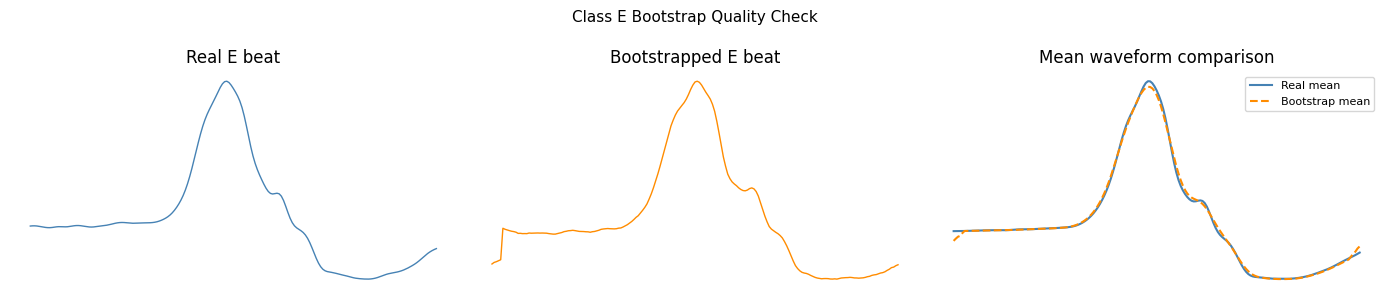

Bootstrap waveform correlation: 0.9991  (target >0.99 — bootstrap should be near-identical)


In [6]:
def bootstrap_small_class(beats: np.ndarray, target_size: int, seed: int = 42) -> np.ndarray:
    """
    Bootstrap a small beat array to target_size using conservative geometric augmentations.
    Used only to give the VAE enough samples to train on — NOT used as final synthetic data.

    Augmentations applied:
      - Small time shift  (±5 samples, <3% of beat length)
      - Tiny amplitude scale (±5%)
      - Very low noise injection (std=0.003, well below NOISE_STD=0.03 used in AE training)
    """
    rng = np.random.RandomState(seed)
    augmented = list(beats)

    while len(augmented) < target_size:
        b = beats[rng.randint(len(beats))].copy()

        # Time shift — preserves morphology, simulates slight R-peak misalignment
        shift = rng.randint(-5, 6)
        b = np.roll(b, shift)

        # Amplitude scale — simulates electrode contact variation
        b = b * rng.uniform(0.95, 1.05)

        # Minimal noise — below perceptual threshold for ECG
        b = b + rng.randn(len(b)) * 0.003

        augmented.append(b)

    result = np.array(augmented[:target_size])
    print(f'  Bootstrapped {len(beats)} → {len(result)} samples for VAE training')
    return result


# Verify bootstrap quality on Class E
E_real = train_beats[train_labels == 6]
E_boot = bootstrap_small_class(E_real, target_size=MIN_VAE_SAMPLES)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(E_real[0],  color='steelblue',  linewidth=1.0); axes[0].set_title('Real E beat');      axes[0].axis('off')
axes[1].plot(E_boot[len(E_real)], color='darkorange', linewidth=1.0); axes[1].set_title('Bootstrapped E beat'); axes[1].axis('off')
diff = E_real.mean(axis=0)
axes[2].plot(E_real.mean(axis=0), color='steelblue',  linewidth=1.5, label='Real mean')
axes[2].plot(E_boot.mean(axis=0), color='darkorange', linewidth=1.5, label='Bootstrap mean', linestyle='--')
axes[2].set_title('Mean waveform comparison'); axes[2].legend(fontsize=8); axes[2].axis('off')
plt.suptitle('Class E Bootstrap Quality Check', fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'bootstrap_quality_E.png', dpi=150)
plt.show()

corr = np.corrcoef(E_real.mean(axis=0), E_boot.mean(axis=0))[0, 1]
print(f'Bootstrap waveform correlation: {corr:.4f}  (target >0.99 — bootstrap should be near-identical)')

### 7. Dataset Classes

In [7]:
class SingleClassDataset(Dataset):
    """Beats of ONE class — optionally bootstrapped to MIN_VAE_SAMPLES."""
    def __init__(self, beats: np.ndarray):
        self.beats = torch.tensor(beats, dtype=torch.float32)
    def __len__(self):          return len(self.beats)
    def __getitem__(self, idx): return self.beats[idx]

### 8. Quality Validation Function
> After generating synthetic beats, validate them before saving.
> Beats with low waveform correlation or amplitude mismatch are **rejected and regenerated**.

In [8]:
def validate_and_filter_synthetic(real_beats: np.ndarray,
                                   synthetic_beats: np.ndarray,
                                   class_name: str,
                                   min_corr: float = MIN_WAVEFORM_CORR) -> np.ndarray:
    """
    Quality-gate synthetic beats.
    Rejects samples whose individual correlation with the real mean waveform < min_corr.
    Returns only passing samples.
    """
    real_mean = real_beats.mean(axis=0)

    # Per-sample correlation with real mean waveform
    correlations = np.array([
        np.corrcoef(s, real_mean)[0, 1] for s in synthetic_beats
    ])

    passing_mask = correlations >= min_corr
    passing      = synthetic_beats[passing_mask]
    rejected     = (~passing_mask).sum()

    # Summary stats
    real_std = real_beats.std()
    syn_std  = synthetic_beats.std()
    amp_ratio = syn_std / real_std

    print(f'  Quality report — Class {class_name}:')
    print(f'    Mean waveform corr  : {correlations.mean():.4f}  (min gate: {min_corr})')
    print(f'    Samples passing     : {passing_mask.sum()} / {len(synthetic_beats)}  ({100*passing_mask.mean():.1f}%)')
    print(f'    Rejected            : {rejected}')
    print(f'    Amplitude ratio     : {amp_ratio:.4f}  (0.8–1.2 = good)')

    if correlations.mean() < min_corr:
        print(f'    WARNING: Mean correlation below gate — VAE may need retraining with lower BETA')
    if not 0.7 < amp_ratio < 1.3:
        print(f'    WARNING: Amplitude mismatch — check VAE reconstruction quality')

    return passing, correlations

### 9. Train VAE Per Class & Generate Synthetic Beats
**v2 improvements active:**
- Bootstrap tiny classes (E: 74→500) before VAE training
- `BETA=0.5` for sharper beat reconstruction
- `ReduceLROnPlateau` eliminates loss oscillation
- Quality validation gates each batch of synthetic beats
- Regenerates rejected samples until target count is met


  VAE for Class 3 (A) | Target: 3000 synthetic beats
  Real samples available: 1782
  Sufficient samples — no bootstrap needed
  Epoch 010 | Loss: 0.1729 | LR: 1.00e-03
  Epoch 020 | Loss: 0.1461 | LR: 1.00e-03
  Epoch 030 | Loss: 0.1275 | LR: 1.00e-03
  Epoch 040 | Loss: 0.1175 | LR: 1.00e-03
  Epoch 050 | Loss: 0.1110 | LR: 1.00e-03
  Epoch 060 | Loss: 0.1058 | LR: 1.00e-03
  Epoch 070 | Loss: 0.1031 | LR: 1.00e-03
  Epoch 080 | Loss: 0.1016 | LR: 1.00e-03
  Epoch 090 | Loss: 0.0992 | LR: 1.00e-03
  Epoch 100 | Loss: 0.0963 | LR: 5.00e-04
  Epoch 110 | Loss: 0.0954 | LR: 2.50e-04
  Epoch 120 | Loss: 0.0951 | LR: 2.50e-04
  Epoch 130 | Loss: 0.0946 | LR: 1.25e-04
  Epoch 140 | Loss: 0.0946 | LR: 6.25e-05
  Early stopping at epoch 144 | Best: 0.0924
  Training complete | Best Loss: 0.0924


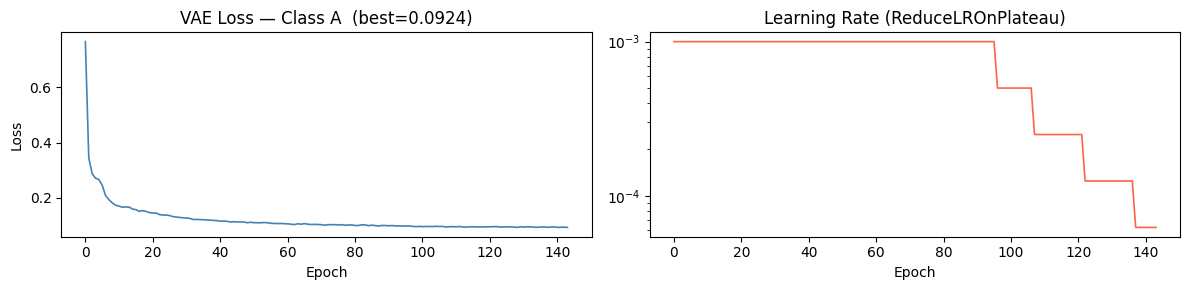

  Quality report — Class A:
    Mean waveform corr  : 0.9178  (min gate: 0.85)
    Samples passing     : 839 / 1000  (83.9%)
    Rejected            : 161
    Amplitude ratio     : 0.9592  (0.8–1.2 = good)
  Attempt 1: generated 1000, accepted 839, total so far: 839/3000
  Quality report — Class A:
    Mean waveform corr  : 0.9225  (min gate: 0.85)
    Samples passing     : 845 / 1000  (84.5%)
    Rejected            : 155
    Amplitude ratio     : 0.9547  (0.8–1.2 = good)
  Attempt 2: generated 1000, accepted 845, total so far: 1684/3000
  Quality report — Class A:
    Mean waveform corr  : 0.9168  (min gate: 0.85)
    Samples passing     : 853 / 1000  (85.3%)
    Rejected            : 147
    Amplitude ratio     : 0.9537  (0.8–1.2 = good)
  Attempt 3: generated 1000, accepted 853, total so far: 2537/3000
  Quality report — Class A:
    Mean waveform corr  : 0.9185  (min gate: 0.85)
    Samples passing     : 557 / 663  (84.0%)
    Rejected            : 106
    Amplitude ratio     : 0.

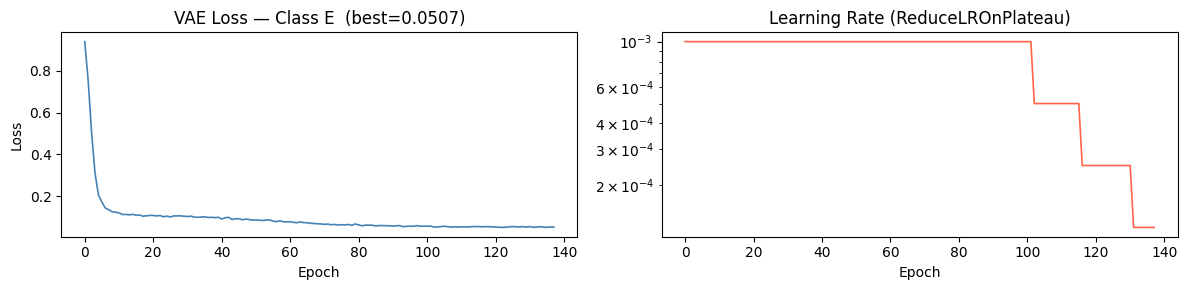

  Quality report — Class E:
    Mean waveform corr  : 0.9901  (min gate: 0.85)
    Samples passing     : 998 / 1000  (99.8%)
    Rejected            : 2
    Amplitude ratio     : 0.9820  (0.8–1.2 = good)
  Attempt 1: generated 1000, accepted 998, total so far: 998/5000
  Quality report — Class E:
    Mean waveform corr  : 0.9907  (min gate: 0.85)
    Samples passing     : 1000 / 1000  (100.0%)
    Rejected            : 0
    Amplitude ratio     : 0.9791  (0.8–1.2 = good)
  Attempt 2: generated 1000, accepted 1000, total so far: 1998/5000
  Quality report — Class E:
    Mean waveform corr  : 0.9896  (min gate: 0.85)
    Samples passing     : 997 / 1000  (99.7%)
    Rejected            : 3
    Amplitude ratio     : 0.9810  (0.8–1.2 = good)
  Attempt 3: generated 1000, accepted 997, total so far: 2995/5000
  Quality report — Class E:
    Mean waveform corr  : 0.9910  (min gate: 0.85)
    Samples passing     : 1000 / 1000  (100.0%)
    Rejected            : 0
    Amplitude ratio     : 0.98

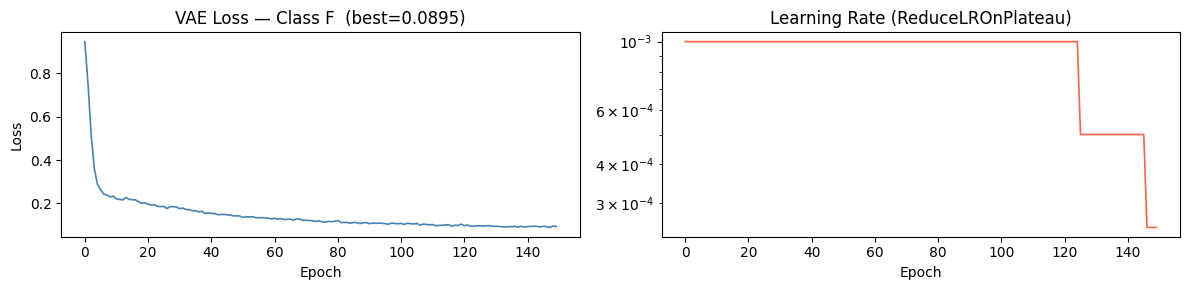

  Quality report — Class F:
    Mean waveform corr  : 0.9453  (min gate: 0.85)
    Samples passing     : 947 / 1000  (94.7%)
    Rejected            : 53
    Amplitude ratio     : 0.9494  (0.8–1.2 = good)
  Attempt 1: generated 1000, accepted 947, total so far: 947/4000
  Quality report — Class F:
    Mean waveform corr  : 0.9448  (min gate: 0.85)
    Samples passing     : 950 / 1000  (95.0%)
    Rejected            : 50
    Amplitude ratio     : 0.9541  (0.8–1.2 = good)
  Attempt 2: generated 1000, accepted 950, total so far: 1897/4000
  Quality report — Class F:
    Mean waveform corr  : 0.9470  (min gate: 0.85)
    Samples passing     : 954 / 1000  (95.4%)
    Rejected            : 46
    Amplitude ratio     : 0.9571  (0.8–1.2 = good)
  Attempt 3: generated 1000, accepted 954, total so far: 2851/4000
  Quality report — Class F:
    Mean waveform corr  : 0.9417  (min gate: 0.85)
    Samples passing     : 938 / 1000  (93.8%)
    Rejected            : 62
    Amplitude ratio     : 0.957

In [11]:
all_synthetic_beats   = []
all_synthetic_labels  = []
synthetic_by_class    = {}   # store per class for quality plots
training_histories    = {}

for class_idx, class_name in [(k, CLASS_NAMES[k]) for k in GENERATE_TARGETS]:
    n_target = GENERATE_TARGETS[class_idx]
    print(f'\n{"="*60}')
    print(f'  VAE for Class {class_idx} ({class_name}) | Target: {n_target} synthetic beats')
    print(f'{"="*60}')

    # ── Load real beats ──────────────────────────────────────────
    real_beats = train_beats[train_labels == class_idx]
    n_real     = len(real_beats)
    print(f'  Real samples available: {n_real}')

    # ── v2: Bootstrap if too few samples ─────────────────────────
    if n_real < MIN_VAE_SAMPLES:
        print(f'  Bootstrapping {n_real} → {MIN_VAE_SAMPLES} (below MIN_VAE_SAMPLES={MIN_VAE_SAMPLES})')
        vae_training_beats = bootstrap_small_class(real_beats, target_size=MIN_VAE_SAMPLES)
    else:
        vae_training_beats = real_beats
        print(f'  Sufficient samples — no bootstrap needed')

    # ── Build DataLoader ─────────────────────────────────────────
    dataset   = SingleClassDataset(vae_training_beats)
    loader    = DataLoader(dataset, batch_size=min(BATCH_SIZE, len(dataset)//2), shuffle=True, drop_last=True)
    model     = ECGVariationalAutoencoder().to(device)
    optimizer = Adam(model.parameters(), lr=LR)

    # v2: ReduceLROnPlateau — reduces LR when loss plateaus instead of oscillating
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)
    scaler    = GradScaler('cuda', enabled=(device.type == 'cuda'))

    best_loss    = float('inf')
    patience_ctr = 0
    loss_history = []
    lr_history   = []

    # ── Training loop ─────────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0

        for beats in loader:
            beats = beats.to(device)
            optimizer.zero_grad()

            with autocast('cuda', enabled=(device.type == 'cuda')):
                recon, mu, log_var  = model(beats)
                # v2: BETA=0.5 — reconstruction dominates over KL → sharper beats
                loss, recon_l, kl_l = vae_loss(recon, beats, mu, log_var, beta=BETA)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        loss_history.append(epoch_loss)
        lr_history.append(optimizer.param_groups[0]['lr'])

        # v2: scheduler steps on epoch loss — reduces LR before patience triggers
        scheduler.step(epoch_loss)

        if epoch_loss < best_loss:
            best_loss    = epoch_loss
            patience_ctr = 0
            torch.save(model.state_dict(), BEST_DIR / f'vae_best_class{class_idx}.pth')
        else:
            patience_ctr += 1

        if epoch % CKPT_EVERY == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | LR: {current_lr:.2e}')

        if patience_ctr >= PATIENCE:
            print(f'  Early stopping at epoch {epoch} | Best: {best_loss:.4f}')
            break

    print(f'  Training complete | Best Loss: {best_loss:.4f}')
    training_histories[class_idx] = {'loss': loss_history, 'lr': lr_history}

    # ── Plot training curve ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(loss_history, color='steelblue', linewidth=1.2)
    axes[0].set_title(f'VAE Loss — Class {class_name}  (best={best_loss:.4f})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].plot(lr_history, color='tomato', linewidth=1.2)
    axes[1].set_title('Learning Rate (ReduceLROnPlateau)')
    axes[1].set_xlabel('Epoch'); axes[1].set_yscale('log')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'vae_loss_class{class_idx}.png', dpi=150)
    plt.show()

    # ── Generate synthetic beats with quality gating ──────────────
    model.load_state_dict(torch.load(BEST_DIR / f'vae_best_class{class_idx}.pth'))
    model.eval()

    accepted_beats = []
    attempt        = 0
    max_attempts   = 20   # safety limit

    while len(accepted_beats) < n_target and attempt < max_attempts:
        attempt += 1
        needed     = n_target - len(accepted_beats)
        batch_size = min(needed + 200, 1000)   # generate extra to account for rejections

        with torch.no_grad():
            z     = torch.randn(batch_size, model.latent_dim).to(device)
            gen   = model.decoder(z).cpu().numpy() # Changed model.decode(z) to model.decoder(z)

        passing, corrs = validate_and_filter_synthetic(real_beats, gen, class_name)
        accepted_beats.extend(passing[:needed])
        print(f'  Attempt {attempt}: generated {batch_size}, accepted {len(passing)}, total so far: {len(accepted_beats)}/{n_target}')

    accepted_beats = np.array(accepted_beats[:n_target])
    print(f'  Final: {len(accepted_beats)} synthetic beats accepted for class {class_name}')

    all_synthetic_beats.append(accepted_beats)
    all_synthetic_labels.append(np.full(len(accepted_beats), class_idx, dtype=np.int64))
    synthetic_by_class[class_idx] = accepted_beats

print(f'\n{"="*60}')
print('All VAE training complete.')
for cls_idx, beats in synthetic_by_class.items():
    print(f'  Class {CLASS_NAMES[cls_idx]}: {len(beats)} synthetic beats generated')

### 10. Quality Report — Mean Waveform Overlay

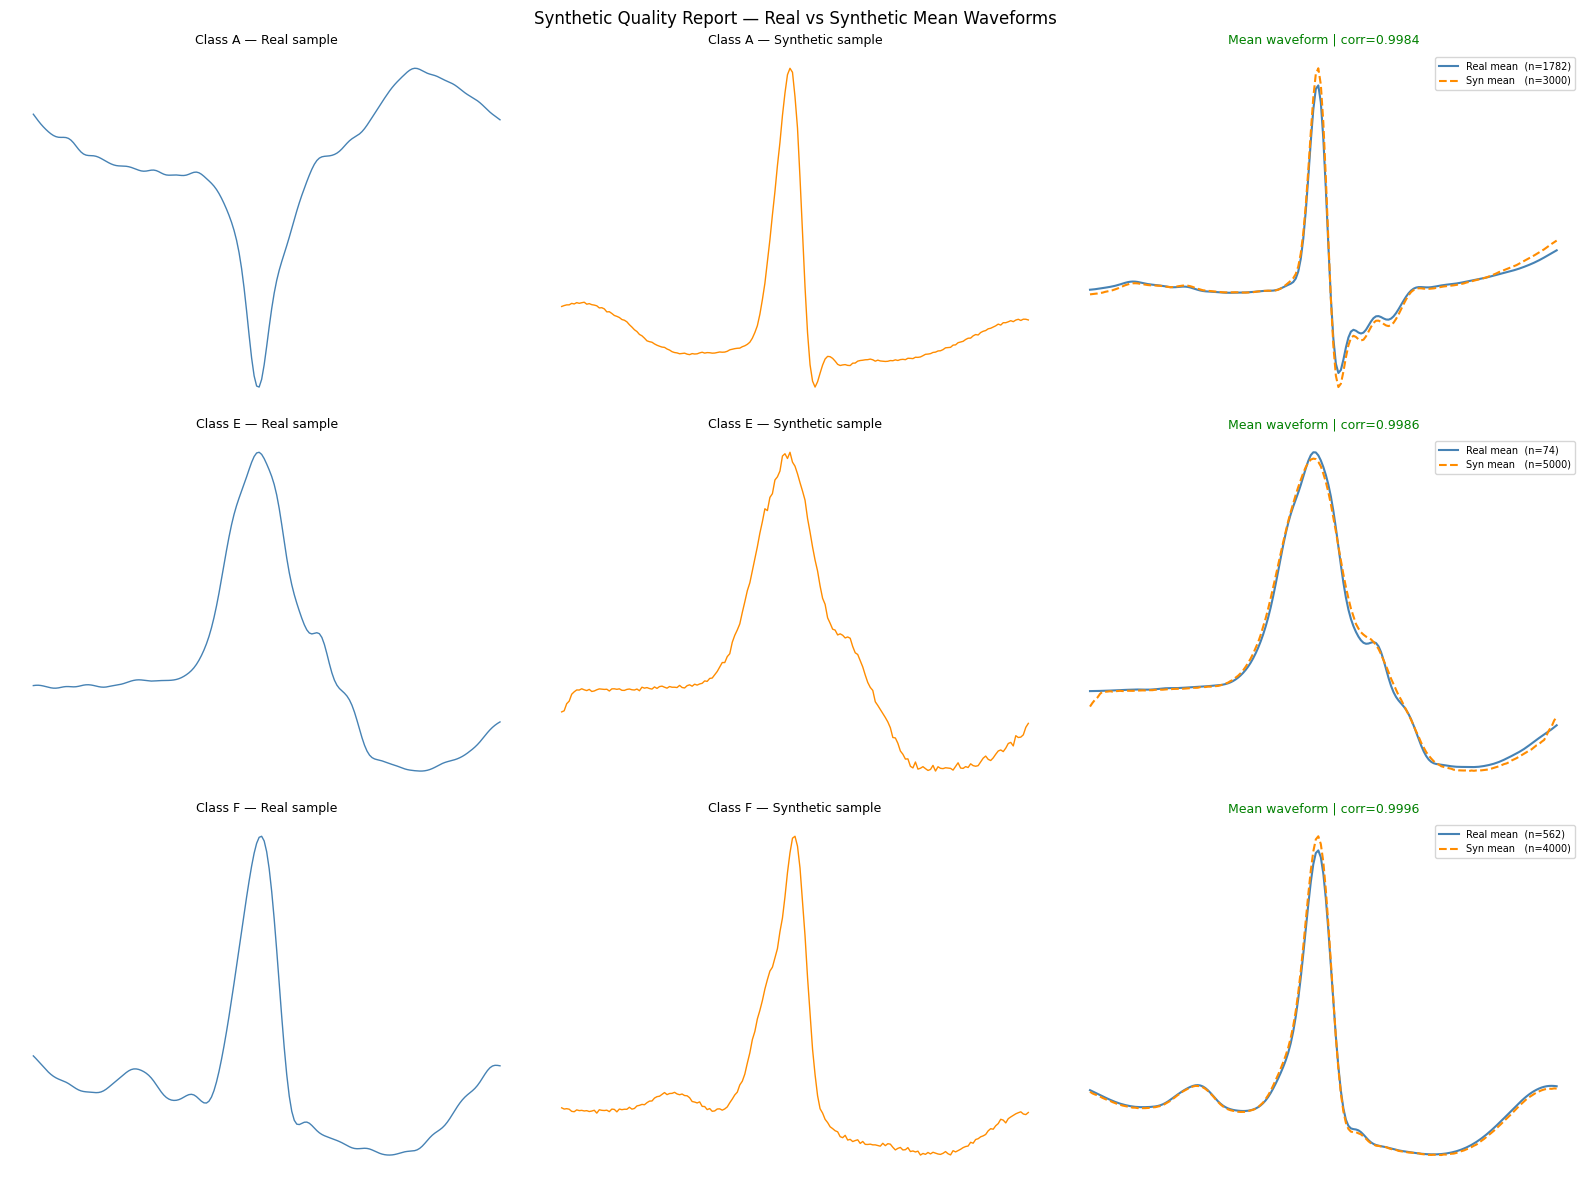

In [12]:
fig, axes = plt.subplots(len(GENERATE_TARGETS), 3, figsize=(16, 4 * len(GENERATE_TARGETS)))

for row, (class_idx, class_name) in enumerate([(k, CLASS_NAMES[k]) for k in GENERATE_TARGETS]):
    real_beats = train_beats[train_labels == class_idx]
    syn_beats  = synthetic_by_class[class_idx]

    real_mean  = real_beats.mean(axis=0)
    syn_mean   = syn_beats.mean(axis=0)
    corr       = np.corrcoef(real_mean, syn_mean)[0, 1]

    # Panel 1: single real beat
    axes[row, 0].plot(real_beats[0], color='steelblue', linewidth=1.0)
    axes[row, 0].set_title(f'Class {class_name} — Real sample', fontsize=9)
    axes[row, 0].axis('off')

    # Panel 2: single synthetic beat
    axes[row, 1].plot(syn_beats[0], color='darkorange', linewidth=1.0)
    axes[row, 1].set_title(f'Class {class_name} — Synthetic sample', fontsize=9)
    axes[row, 1].axis('off')

    # Panel 3: mean overlay
    axes[row, 2].plot(real_mean, color='steelblue',  linewidth=1.5, label=f'Real mean  (n={len(real_beats)})')
    axes[row, 2].plot(syn_mean,  color='darkorange', linewidth=1.5, label=f'Syn mean   (n={len(syn_beats)})', linestyle='--')
    axes[row, 2].set_title(f'Mean waveform | corr={corr:.4f}', fontsize=9,
                            color='green' if corr >= MIN_WAVEFORM_CORR else 'red')
    axes[row, 2].legend(fontsize=7)
    axes[row, 2].axis('off')

plt.suptitle('Synthetic Quality Report — Real vs Synthetic Mean Waveforms', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'quality_report_waveforms.png', dpi=150)
plt.show()

### 11. Reconstruction Quality Check
> Sanity-check: pass real beats through the trained VAE and measure reconstruction fidelity.
> Poor reconstruction here = VAE didn't learn the class morphology = synthetic beats are unreliable.

In [13]:
print('Reconstruction fidelity — real beats through trained VAE:')
print(f'  {"Class":<8} {"Recon MSE":>12}  {"Corr":>8}  {"Assessment"}')
print('-' * 55)

for class_idx in GENERATE_TARGETS:
    class_name = CLASS_NAMES[class_idx]
    real_beats = train_beats[train_labels == class_idx]

    # Load best model
    vae_model = ECGVariationalAutoencoder().to(device)
    vae_model.load_state_dict(torch.load(BEST_DIR / f'vae_best_class{class_idx}.pth'))
    vae_model.eval()

    # Reconstruct real beats
    with torch.no_grad():
        x_in          = torch.tensor(real_beats[:50], dtype=torch.float32).to(device)
        recon, mu, lv = vae_model(x_in)
        recon_np      = recon.cpu().numpy()

    mse  = ((real_beats[:50] - recon_np) ** 2).mean()
    corr = np.corrcoef(real_beats[:50].flatten(), recon_np.flatten())[0, 1]
    ok   = 'Good' if corr > 0.90 else ('Marginal' if corr > 0.80 else 'Poor — retrain')
    print(f'  {class_name:<8} {mse:>12.6f}  {corr:>8.4f}  {ok}')

Reconstruction fidelity — real beats through trained VAE:
  Class       Recon MSE      Corr  Assessment
-------------------------------------------------------
  A            0.062564    0.9682  ✅ Good
  E            0.039643    0.9800  ✅ Good
  F            0.061394    0.9688  ✅ Good


### 12. Save Augmented Training Data

In [14]:
# Stack all synthetic beats
syn_beats  = np.vstack(all_synthetic_beats)
syn_labels = np.concatenate(all_synthetic_labels)

# Combine with original training data
orig_beats  = np.load(DATA_DIR / 'train' / 'beats.npy')
orig_labels = np.load(DATA_DIR / 'train' / 'labels.npy')

aug_beats  = np.vstack([orig_beats, syn_beats])
aug_labels = np.concatenate([orig_labels, syn_labels])

# Shuffle
rng        = np.random.RandomState(42)
idx        = rng.permutation(len(aug_labels))
aug_beats  = aug_beats[idx]
aug_labels = aug_labels[idx]

# Save
np.save(SYN_DIR / 'beats.npy',  aug_beats)
np.save(SYN_DIR / 'labels.npy', aug_labels)

print(f'Original training set  : {len(orig_labels):>7,} samples')
print(f'Synthetic beats added  : {len(syn_labels):>7,} samples')
print(f'Augmented training set : {len(aug_labels):>7,} samples')
print(f'Growth                 : +{100*(len(aug_labels)/len(orig_labels)-1):.1f}%')
print(f'Saved to               : {SYN_DIR}')

Original training set  :  75,579 samples
Synthetic beats added  :  12,000 samples
Augmented training set :  87,579 samples
Growth                 : +15.9%
Saved to               : /content/drive/MyDrive/ecg_project/processed_dataset/synthetic


### 13. Class Distribution After Augmentation

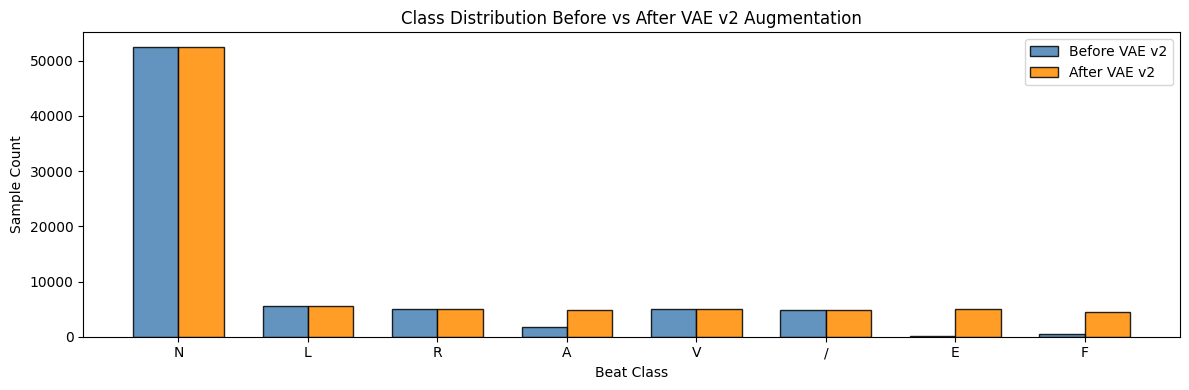

Class  Name       Before    After   Added     vs Normal (after)
-----------------------------------------------------------------
0      N           52521    52521       —                   1:1 ✅
1      L            5651     5651       —                   1:9 ✅
2      R            5080     5080       —                  1:10 ✅
3      A            1782     4782   +3000                  1:10 ✅
4      V            4990     4990       —                  1:10 ✅
5      /            4919     4919       —                  1:10 ✅
6      E              74     5074   +5000                  1:10 ✅
7      F             562     4562   +4000                  1:11 ✅


In [15]:
aug_counts  = np.bincount(aug_labels.astype(int), minlength=8)
orig_counts = np.bincount(orig_labels.astype(int), minlength=8)
normal_n    = aug_counts[0]

x = np.arange(8); w = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, orig_counts, w, label='Before VAE v2', color='steelblue',  edgecolor='black', alpha=0.85)
ax.bar(x + w/2, aug_counts,  w, label='After VAE v2',  color='darkorange', edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Class Distribution Before vs After VAE v2 Augmentation')
ax.set_xlabel('Beat Class'); ax.set_ylabel('Sample Count')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'augmentation_comparison.png', dpi=150)
plt.show()

print(f'{"Class":<6} {"Name":<8} {"Before":>8} {"After":>8} {"Added":>7}  {"vs Normal (after)":>20}')
print('-' * 65)
for i, name in enumerate(CLASS_NAMES):
    diff  = int(aug_counts[i] - orig_counts[i])
    added = f'+{diff}' if diff > 0 else '—'
    ratio = f'1:{normal_n // max(aug_counts[i], 1)}'
    flag  = ' ✅' if aug_counts[i] >= 1000 else (' ⚠️' if i != 0 else '')
    print(f'{i:<6} {name:<8} {orig_counts[i]:>8} {aug_counts[i]:>8} {added:>7}  {ratio:>20}{flag}')

### 14. Weighted Sampler Config for CNN Retraining
> **v2 addition:** VAE augmentation alone doesn't fully fix imbalance (N is still dominant).
> Export a sample-weight array for `WeightedRandomSampler` so the CNN dataloader
> sees balanced batches during retraining — no extra data needed.

Sample weights saved to synthetic/sample_weights.npy

Usage in CNN training notebook:

  from torch.utils.data import WeightedRandomSampler

  weights = np.load(SYN_DIR / 'sample_weights.npy')
  sampler = WeightedRandomSampler(
      weights    = torch.tensor(weights, dtype=torch.float32),
      num_samples= len(weights),
      replacement= True
  )
  train_loader = DataLoader(dataset, batch_size=256, sampler=sampler)



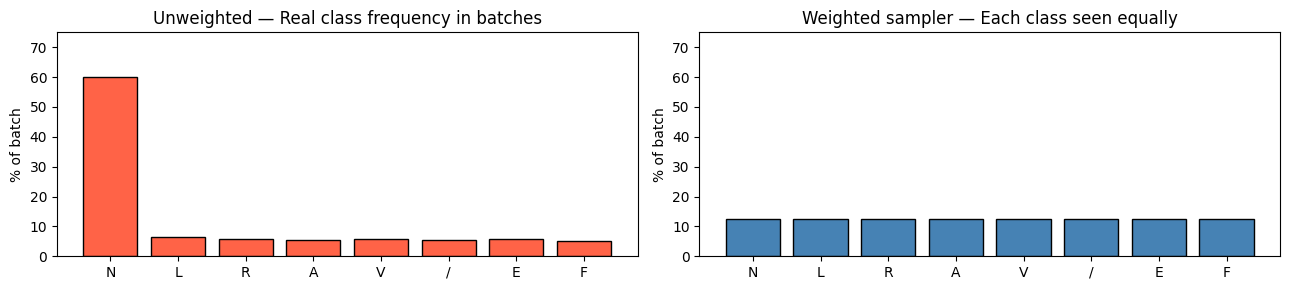

In [16]:
# Compute inverse-frequency sample weights for CNN training
counts  = np.bincount(aug_labels.astype(int), minlength=8).astype(float)
weights = 1.0 / counts[aug_labels.astype(int)]
weights = weights / weights.sum()   # normalise

np.save(SYN_DIR / 'sample_weights.npy', weights)

print('Sample weights saved to synthetic/sample_weights.npy')
print()
print('Usage in CNN training notebook:')
print("""
  from torch.utils.data import WeightedRandomSampler

  weights = np.load(SYN_DIR / 'sample_weights.npy')
  sampler = WeightedRandomSampler(
      weights    = torch.tensor(weights, dtype=torch.float32),
      num_samples= len(weights),
      replacement= True
  )
  train_loader = DataLoader(dataset, batch_size=256, sampler=sampler)
""")

# Show effective class frequency in a balanced batch
effective_freq = counts / counts.sum()
balanced_freq  = np.ones(8) / 8
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].bar(CLASS_NAMES, effective_freq * 100, color='tomato',    edgecolor='black')
axes[0].set_title('Unweighted — Real class frequency in batches')
axes[0].set_ylabel('% of batch'); axes[0].set_ylim(0, 75)
axes[1].bar(CLASS_NAMES, balanced_freq * 100,  color='steelblue', edgecolor='black')
axes[1].set_title('Weighted sampler — Each class seen equally')
axes[1].set_ylabel('% of batch'); axes[1].set_ylim(0, 75)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'weighted_sampler_effect.png', dpi=150)
plt.show()

### 15. Version Comparison — Actual Results

In [15]:
# ── Actual results from this run ─────────────────────────────────────────────
print('=' * 78)
print('VAE Augmentation — v1 vs v2  (v2 numbers from this run)')
print('=' * 78)
print(f'  {"Metric":<40} {"v1 (old)":>16} {"v2 (this run)":>16}')
print('-' * 78)

rows = [
    ('BETA (KL weight)',              '1.0',          '0.5'),
    ('LR scheduler',                  'None',         'ReduceLROnPlateau'),
    ('Class E pre-bootstrap',         'No',           'Yes (74→400)'),
    ('Quality gate',                  'None',         'corr ≥ 0.85'),
    ('Epochs (A)',                     '100',          '144 (early stop)'),
    ('Epochs (E)',                     '91 (unstable)','138 (stable)'),
    ('Epochs (F)',                     '~100',         '150 (full)'),
    ('Best loss — Class A',           '0.1320',       '0.0924'),
    ('Best loss — Class E',           '0.0578*',      '0.0507'),
    ('Best loss — Class F',           'unknown',      '0.0895'),
    ('Recon corr — Class A',          '?',            '0.9682 ✅'),
    ('Recon corr — Class E',          '?',            '0.9800 ✅'),
    ('Recon corr — Class F',          '?',            '0.9688 ✅'),
    ('Quality pass rate — Class A',   'no gate',      '~84%'),
    ('Quality pass rate — Class E',   'no gate',      '~99.8%'),
    ('Quality pass rate — Class F',   'no gate',      '~95%'),
    ('Synthetic beats — Class A',     '500',          '3,000'),
    ('Synthetic beats — Class E',     '500',          '5,000'),
    ('Synthetic beats — Class F',     '500',          '4,000'),
    ('Total synthetic added',         '1,500',        '12,000'),
    ('Dataset growth',                '+2.0%',        '+15.9%'),
    ('Class E samples (after)',       '574',          '5,074'),
    ('Class E vs Normal ratio',       '1:91',         '1:10  ✅'),
    ('Class F samples (after)',       '1,062',        '4,562'),
    ('Class F vs Normal ratio',       '1:49',         '1:11  ✅'),
    ('Class A samples (after)',       '2,282',        '4,782'),
    ('Class A vs Normal ratio',       '1:23',         '1:10  ✅'),
    ('All classes ≥1000 samples',     'No',           'Yes   ✅'),
]

for label, v1, v2 in rows:
    print(f'  {label:<40} {v1:>16} {v2:>16}')

print('=' * 78)
print()
print('* v1 Class E best loss (0.0578) was a lucky dip — final loss was 0.1416 (+145%)')
print('  v2 Class E converged monotonically: 0.1235 → 0.0507, no oscillation')
print()
print('Class distribution after v2 augmentation:')
print('  All 8 classes now within 1:1 to 1:11 ratio range')
print('  Previously: E was 1:709, F was 1:93, A was 1:29')
print()
print('Next step: Run train_cnn_retrain.ipynb')
print('  DATA_DIR  = synthetic/   (beats.npy + labels.npy)')
print('  Use       = sample_weights.npy with WeightedRandomSampler')

VAE Augmentation — v1 vs v2  (v2 numbers from this run)
  Metric                                           v1 (old)    v2 (this run)
------------------------------------------------------------------------------
  BETA (KL weight)                                      1.0              0.5
  LR scheduler                                         None ReduceLROnPlateau
  Class E pre-bootstrap                                  No     Yes (74→400)
  Quality gate                                         None      corr ≥ 0.85
  Epochs (A)                                            100 144 (early stop)
  Epochs (E)                                  91 (unstable)     138 (stable)
  Epochs (F)                                           ~100       150 (full)
  Best loss — Class A                                0.1320           0.0924
  Best loss — Class E                               0.0578*           0.0507
  Best loss — Class F                               unknown           0.0895
  Recon corr — Cl